<a href="https://colab.research.google.com/github/nehansa2003/Weather-Forecasting-Project/blob/main/Colombo_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ================================================================
# 1. IMPORT TENSORFLOW AND CONFIGURE GPU
# ================================================================

import tensorflow as tf

# Check available GPUs
gpus = tf.config.list_physical_devices("GPU")

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(
                gpu,
                True
            )

        print("GPU detected:")
        for gpu in gpus:
            print(gpu)

    except RuntimeError as e:
        print("GPU configuration error:", e)

else:
    print("No GPU detected.")


# Display TensorFlow version
print("\nTensorFlow version:", tf.__version__)

# Display GPU devices
print(
    "Available GPUs:",
    tf.config.list_physical_devices("GPU")
)

No GPU detected.

TensorFlow version: 2.20.0
Available GPUs: []


In [2]:
from google.colab import drive
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
import joblib
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import psutil
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
print("Keras imports successful!")

Keras imports successful!


In [3]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [4]:
ram = psutil.virtual_memory()

print(f"System RAM total: {ram.total / 1024**3:.2f} GB")
print(f"System RAM available: {ram.available / 1024**3:.2f} GB")

System RAM total: 12.67 GB
System RAM available: 11.34 GB


In [5]:
!nvidia-smi --query-gpu=name,memory.total,memory.used,memory.free --format=csv

/bin/bash: line 1: nvidia-smi: command not found


In [6]:
drive.mount("/content/drive")

Mounted at /content/drive


In [7]:
# ================================================================
# LOAD PROCESSED WEATHER DATA
# ================================================================

DATA_PATH = (
    '/content/drive/MyDrive/Capstone_Datasets/colombo_weather.parquet'
)

weather_df = pd.read_parquet(
    DATA_PATH,
    engine="pyarrow"
)

print("Dataset loaded successfully!")

print("Shape:", weather_df.shape)

print("\nColumns:")
print(weather_df.columns.tolist())

print("\nDate range:")
print(
    weather_df["datetime"].min(),
    "to",
    weather_df["datetime"].max()
)

Dataset loaded successfully!
Shape: (578688, 35)

Columns:
['district', 'pointid', 'global_pointid', 'latitude', 'longitude', 'elevation_m', 'datetime', 'date', 'day', 'month', 'year', 'time', 'season', 'hour', 'day_of_week', 'day_of_year', 'is_weekend', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'temperature_c', 'feelslike_c', 'humidity_pct', 'dewpoint_c', 'pressure_hpa', 'windspeed_kmh', 'winddirection_deg', 'winddirection_compass', 'windgust_kmh', 'rainfall_mm', 'cloudcover_pct', 'solarradiation_wm2', 'sunshineduration_s', 'rain_occurs']

Date range:
2020-01-01 00:00:00 to 2025-12-31 23:00:00


In [8]:
weather_df["datetime"] = pd.to_datetime(
    weather_df["datetime"]
)

weather_df = weather_df.sort_values(
    ["district", "pointid", "datetime"]
).reset_index(drop=True)

print("Data sorted successfully.")

Data sorted successfully.


Sequence length

In [9]:
# SEQUENCE CONFIGURATION
LOOKBACK = 24

FORECAST_HORIZON = 1

print("Lookback:", LOOKBACK, "hours")
print("Forecast horizon:", FORECAST_HORIZON, "hour")

Lookback: 24 hours
Forecast horizon: 1 hour


Time-based train/validation/test split

In [10]:
# ================================================================
# TIME-BASED DATA SPLIT
# ================================================================

train_df = weather_df[
    weather_df["year"] <= 2023
].copy()

val_df = weather_df[
    weather_df["year"] == 2024
].copy()

test_df = weather_df[
    weather_df["year"] == 2025
].copy()

print("Training:", train_df.shape)
print("Validation:", val_df.shape)
print("Testing:", test_df.shape)

Training: (385704, 35)
Validation: (96624, 35)
Testing: (96360, 35)


Add Rainfall Probability

In [11]:
# DEFINE RAINFALL OCCURRENCE

RAIN_THRESHOLD = 0.1

train_df["rain_occurs"] = (
    train_df["rainfall_mm"] >= RAIN_THRESHOLD
).astype("int8")

print(
    train_df["rain_occurs"].value_counts()
)

rain_occurs
0    199737
1    185967
Name: count, dtype: int64


In [12]:
# ================================================================
# HISTORICAL RAINFALL PROBABILITY
# CALCULATED USING TRAINING DATA ONLY
# ================================================================

historical_rain_probability = (
    train_df
    .groupby(
        [
            "district",
            "pointid",
            "hour"
        ]
    )["rain_occurs"]
    .mean()
    .reset_index(
        name="historical_rain_probability"
    )
)

print(
    historical_rain_probability.head(20)
)

   district  pointid  hour  historical_rain_probability
0   Colombo        1     0                     0.414100
1   Colombo        1     1                     0.435318
2   Colombo        1     2                     0.446270
3   Colombo        1     3                     0.460643
4   Colombo        1     4                     0.472279
5   Colombo        1     5                     0.464750
6   Colombo        1     6                     0.408624
7   Colombo        1     7                     0.426420
8   Colombo        1     8                     0.466804
9   Colombo        1     9                     0.526352
10  Colombo        1    10                     0.587269
11  Colombo        1    11                     0.635181
12  Colombo        1    12                     0.678303
13  Colombo        1    13                     0.697467
14  Colombo        1    14                     0.681725
15  Colombo        1    15                     0.654346
16  Colombo        1    16                     0

Merge the probability into training data

In [13]:
# ================================================================
# ADD HISTORICAL PROBABILITY TO TRAINING DATA
# ================================================================

train_df = train_df.merge(
    historical_rain_probability[
        [
            "district",
            "pointid",
            "hour",
            "historical_rain_probability"
        ]
    ],
    on=[
        "district",
        "pointid",
        "hour"
    ],
    how="left"
)

print(
    train_df[
        [
            "district",
            "pointid",
            "hour",
            "rainfall_mm",
            "historical_rain_probability"
        ]
    ].head(20)
)

   district  pointid  hour  rainfall_mm  historical_rain_probability
0   Colombo        1     0          0.1                     0.414100
1   Colombo        1     1          0.0                     0.435318
2   Colombo        1     2          0.1                     0.446270
3   Colombo        1     3          0.1                     0.460643
4   Colombo        1     4          0.0                     0.472279
5   Colombo        1     5          0.0                     0.464750
6   Colombo        1     6          0.0                     0.408624
7   Colombo        1     7          0.0                     0.426420
8   Colombo        1     8          0.0                     0.466804
9   Colombo        1     9          0.0                     0.526352
10  Colombo        1    10          0.0                     0.587269
11  Colombo        1    11          0.0                     0.635181
12  Colombo        1    12          0.0                     0.678303
13  Colombo        1    13        

Adding the same training-derived probability to validation data

In [14]:
# ================================================================
# ADD TRAINING-DERIVED PROBABILITY TO VALIDATION DATA
# ================================================================

val_df = val_df.merge(
    historical_rain_probability[
        [
            "district",
            "pointid",
            "hour",
            "historical_rain_probability"
        ]
    ],
    on=[
        "district",
        "pointid",
        "hour"
    ],
    how="left"
)

print(
    val_df[
        [
            "district",
            "pointid",
            "hour",
            "rainfall_mm",
            "historical_rain_probability"
        ]
    ].head(20)
)

   district  pointid  hour  rainfall_mm  historical_rain_probability
0   Colombo        1     0          0.3                     0.414100
1   Colombo        1     1          0.1                     0.435318
2   Colombo        1     2          0.0                     0.446270
3   Colombo        1     3          0.0                     0.460643
4   Colombo        1     4          0.0                     0.472279
5   Colombo        1     5          0.0                     0.464750
6   Colombo        1     6          0.0                     0.408624
7   Colombo        1     7          0.0                     0.426420
8   Colombo        1     8          0.0                     0.466804
9   Colombo        1     9          0.0                     0.526352
10  Colombo        1    10          0.0                     0.587269
11  Colombo        1    11          0.0                     0.635181
12  Colombo        1    12          0.0                     0.678303
13  Colombo        1    13        

Adding the same probability to test data

In [17]:
# ================================================================
# ADD TRAINING-DERIVED PROBABILITY TO TEST DATA
# ================================================================

test_df = test_df.merge(
    historical_rain_probability[
        [
            "district",
            "pointid",
            "hour",
            "historical_rain_probability"
        ]
    ],
    on=[
        "district",
        "pointid",
        "hour"
    ],
    how="left"
)

print(
    test_df[
        [
            "district",
            "pointid",
            "hour",
            "rainfall_mm",
            "historical_rain_probability"
        ]
    ].head(20)
)

   district  pointid  hour  rainfall_mm  historical_rain_probability
0   Colombo        1     0          0.0                     0.414100
1   Colombo        1     1          0.3                     0.435318
2   Colombo        1     2          0.0                     0.446270
3   Colombo        1     3          0.0                     0.460643
4   Colombo        1     4          0.0                     0.472279
5   Colombo        1     5          0.0                     0.464750
6   Colombo        1     6          0.0                     0.408624
7   Colombo        1     7          0.0                     0.426420
8   Colombo        1     8          0.0                     0.466804
9   Colombo        1     9          0.0                     0.526352
10  Colombo        1    10          0.1                     0.587269
11  Colombo        1    11          1.2                     0.635181
12  Colombo        1    12          8.3                     0.678303
13  Colombo        1    13        

In [18]:
# ================================================================
# CHECK FOR MISSING HISTORICAL PROBABILITIES
# ================================================================

print(
    "Training missing:",
    train_df["historical_rain_probability"].isna().sum()
)

print(
    "Validation missing:",
    val_df["historical_rain_probability"].isna().sum()
)

print(
    "Test missing:",
    test_df["historical_rain_probability"].isna().sum()
)

Training missing: 0
Validation missing: 0
Test missing: 0


In [19]:
# ================================================================
# MODEL FEATURES
# ================================================================

features = [
    "temperature_c",
    "humidity_pct",
    "pressure_hpa",
    "windspeed_kmh",
    "rainfall_mm",
    "windgust_kmh",
    "cloudcover_pct",
    "solarradiation_wm2",
    "dewpoint_c",
    "historical_rain_probability"
]

# Keep only available features
features = [
    col for col in features
    if col in train_df.columns
]

print("Features used for modelling:")
print(features)

Features used for modelling:
['temperature_c', 'humidity_pct', 'pressure_hpa', 'windspeed_kmh', 'rainfall_mm', 'windgust_kmh', 'cloudcover_pct', 'solarradiation_wm2', 'dewpoint_c', 'historical_rain_probability']


Define target variables

In [20]:
target_variables = [
    "temperature_c",
    "humidity_pct",
    "pressure_hpa",
    "windspeed_kmh",
    "rainfall_mm",
    "windgust_kmh",
    "cloudcover_pct",
    "solarradiation_wm2",
    "dewpoint_c"
]

target_variables = [
    col for col in target_variables
    if col in weather_df.columns
]

print("Target variables:")
print(target_variables)

LOOKBACK = 24
BATCH_SIZE = 128

Target variables:
['temperature_c', 'humidity_pct', 'pressure_hpa', 'windspeed_kmh', 'rainfall_mm', 'windgust_kmh', 'cloudcover_pct', 'solarradiation_wm2', 'dewpoint_c']


Scale the data

In [21]:
feature_scaler = StandardScaler()

target_scaler = StandardScaler()

feature_scaler.fit(
    train_df[features]
)

target_scaler.fit(
    train_df[target_variables]
)


print("\nScalers fitted using TRAINING data only.")

train_scaled = train_df.copy()

val_scaled = val_df.copy()

test_scaled = test_df.copy()

# SCALE INPUT FEATURES

train_scaled[features] = feature_scaler.transform(
    train_df[features]
)

val_scaled[features] = feature_scaler.transform(
    val_df[features]
)

test_scaled[features] = feature_scaler.transform(
    test_df[features]
)

# SCALE TARGET VARIABLES

train_scaled[target_variables] = target_scaler.transform(
    train_df[target_variables]
)

val_scaled[target_variables] = target_scaler.transform(
    val_df[target_variables]
)

test_scaled[target_variables] = target_scaler.transform(
    test_df[target_variables]
)
print("\nScaling completed successfully.")

print("\nTraining Feature Mean:")
print(
    train_scaled[features].mean()
)

print("\nTraining Feature Standard Deviation:")
print(
    train_scaled[features].std()
)


print("\nTraining Target Mean:")
print(
    train_scaled[target_variables].mean()
)

print("\nTraining Target Standard Deviation:")
print(
    train_scaled[target_variables].std()
)


Scalers fitted using TRAINING data only.

Scaling completed successfully.

Training Feature Mean:
temperature_c                 -3.224360e-15
humidity_pct                  -3.838402e-16
pressure_hpa                   8.432561e-14
windspeed_kmh                 -8.341468e-17
rainfall_mm                   -5.504485e-17
windgust_kmh                   3.611443e-16
cloudcover_pct                 1.474494e-16
solarradiation_wm2            -2.203268e-17
dewpoint_c                     2.776863e-15
historical_rain_probability    1.088151e-16
dtype: float64

Training Feature Standard Deviation:
temperature_c                  1.000001
humidity_pct                   1.000001
pressure_hpa                   1.000001
windspeed_kmh                  1.000001
rainfall_mm                    1.000001
windgust_kmh                   1.000001
cloudcover_pct                 1.000001
solarradiation_wm2             1.000001
dewpoint_c                     1.000001
historical_rain_probability    1.000001
dtype: f

In [22]:
# ================================================================
# SAVE FEATURE AND TARGET SCALERS
# ================================================================
# Google Drive folder
SCALER_DIR = "/content/drive/MyDrive/Capstone_Datasets"

# Create folder if it does not exist
os.makedirs(SCALER_DIR, exist_ok=True)


# Save feature scaler
feature_scaler_path = os.path.join(
    SCALER_DIR,
    "feature_standard_scaler.pkl"
)

joblib.dump(
    feature_scaler,
    feature_scaler_path
)


# Save target scaler
target_scaler_path = os.path.join(
    SCALER_DIR,
    "target_standard_scaler.pkl"
)

joblib.dump(
    target_scaler,
    target_scaler_path
)


print("Scalers saved successfully!")

print("\nFeature scaler:")
print(feature_scaler_path)

print("\nTarget scaler:")
print(target_scaler_path)

Scalers saved successfully!

Feature scaler:
/content/drive/MyDrive/Capstone_Datasets/feature_standard_scaler.pkl

Target scaler:
/content/drive/MyDrive/Capstone_Datasets/target_standard_scaler.pkl


Create sequences

In [ ]:
# ================================================================
# CREATE SEQUENCES
# ================================================================

def sequence_generator(
    df,
    feature_columns,
    target_columns,
    lookback=24
):

    # Process one geographical point at a time
    for (district, pointid), point_df in df.groupby(
        ["district", "pointid"],
        sort=False
    ):

        point_df = point_df.sort_values("datetime")

        X = point_df[feature_columns].values.astype(
            np.float32
        )

        y = point_df[target_columns].values.astype(
            np.float32
        )

        # Generate sequences one at a time
        for i in range(
            lookback,
            len(point_df)
        ):

            X_sequence = X[
                i - lookback:i
            ]

            y_target = y[i]

            yield X_sequence, y_target

In [ ]:
# ================================================================
# CALCULATE NUMBER OF TRAINING SEQUENCES
# ================================================================

LOOKBACK = 24
BATCH_SIZE = 128

train_sequences = 0

for (district, pointid), point_df in train_df.groupby(
    ["district", "pointid"],
    sort=False
):
    n = len(point_df)

    if n > LOOKBACK:
        train_sequences += n - LOOKBACK

print("Total training sequences:", train_sequences)

steps_per_epoch = int(
    np.ceil(train_sequences / BATCH_SIZE)
)

print("Steps per epoch:", steps_per_epoch)

Total training sequences: 385440
Steps per epoch: 3012


In [ ]:
# ================================================================
# CALCULATE VALIDATION SEQUENCES
# ================================================================

val_sequences = 0

for (district, pointid), point_df in val_df.groupby(
    ["district", "pointid"],
    sort=False
):
    n = len(point_df)

    if n > LOOKBACK:
        val_sequences += n - LOOKBACK

print("Total validation sequences:", val_sequences)

validation_steps = int(
    np.ceil(val_sequences / BATCH_SIZE)
)

print("Validation steps:", validation_steps)

Total validation sequences: 96360
Validation steps: 753


Create the TensorFlow dataset

In [ ]:
output_signature = (
    tf.TensorSpec(
        shape=(LOOKBACK, len(features)),
        dtype=tf.float32
    ),

    tf.TensorSpec(
        shape=(len(target_variables),),
        dtype=tf.float32
    )
)

In [ ]:
train_dataset = tf.data.Dataset.from_generator(
    lambda: sequence_generator(
        train_scaled,
        features,
        target_variables,
        LOOKBACK
    ),
    output_signature=output_signature
)

val_dataset = tf.data.Dataset.from_generator(
    lambda: sequence_generator(
        val_scaled,
        features,
        target_variables,
        LOOKBACK
    ),
    output_signature=output_signature
)

In [ ]:
# ================================================================
# CREATE TEST SEQUENCES
# ================================================================

test_dataset = tf.data.Dataset.from_generator(
    lambda: sequence_generator(
        test_scaled,
        features,
        target_variables,
        LOOKBACK
    ),
    output_signature=output_signature
)

Batch the sequences

In [ ]:
train_dataset = (
    train_dataset
    .repeat()
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_dataset = (
    val_dataset
    .repeat()
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_dataset = (
    test_dataset
    #.repeat()
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

In [ ]:
test_dataset = tf.data.Dataset.from_generator(
    lambda: sequence_generator(
        test_scaled,
        features,
        target_variables,
        LOOKBACK
    ),
    output_signature=output_signature
)

test_dataset = (
    test_dataset
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

In [ ]:
# ================================================================
# CHECK ACTUAL INPUT AND TARGET BATCH
# ================================================================

for X_batch, y_batch in train_dataset.take(1):

    print("X shape:", X_batch.shape)
    print("Y shape:", y_batch.shape)

    print("\nX mean:", tf.reduce_mean(X_batch).numpy())
    print("X std:", tf.math.reduce_std(X_batch).numpy())

    print("\nY mean:", tf.reduce_mean(y_batch).numpy())
    print("Y std:", tf.math.reduce_std(y_batch).numpy())

    print("\nX min:", tf.reduce_min(X_batch).numpy())
    print("X max:", tf.reduce_max(X_batch).numpy())

    print("\nY min:", tf.reduce_min(y_batch).numpy())
    print("Y max:", tf.reduce_max(y_batch).numpy())

X shape: (128, 24, 10)
Y shape: (128, 9)

X mean: -0.15145855
X std: 0.99298763

Y mean: -0.20514196
Y std: 0.97358453

X min: -2.3844535
X max: 2.7085087

Y min: -2.3844535
Y max: 2.7085087


Build the LSTM model

In [ ]:
# ================================================================
# BUILD LSTM MODEL
# ================================================================

model = Sequential([

    LSTM(
        64,
        return_sequences=True,
        input_shape=(
            LOOKBACK,
            len(features)
        )
    ),

    Dropout(0.2),

    LSTM(32),

    Dropout(0.2),

    Dense(32, activation="relu"),

    Dense(
        len(target_variables),
        activation="linear"
    )
])


model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 64)         │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │           297 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,969 (128.79 KB)

 Trainable params: 32,969 (128.79 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ================================================================
# LSTM TRAINING
# ================================================================

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

In [ ]:
history = model.fit(
    train_dataset,

    validation_data=val_dataset,

    epochs=30,

    steps_per_epoch=steps_per_epoch,

    validation_steps=validation_steps,

    callbacks=[
        early_stopping,
        reduce_lr
    ]
)

Epoch 1/30
3012/3012 ━━━━━━━━━━━━━━━━━━━━ 319s 105ms/step - loss: 0.2915 - mae: 0.3470 - val_loss: 0.2234 - val_mae: 0.2820 - learning_rate: 0.0010
Epoch 2/30
3012/3012 ━━━━━━━━━━━━━━━━━━━━ 315s 105ms/step - loss: 0.2039 - mae: 0.2746 - val_loss: 0.2102 - val_mae: 0.2654 - learning_rate: 0.0010
Epoch 3/30
3012/3012 ━━━━━━━━━━━━━━━━━━━━ 321s 106ms/step - loss: 0.1922 - mae: 0.2650 - val_loss: 0.2021 - val_mae: 0.2552 - learning_rate: 0.0010
Epoch 4/30
3012/3012 ━━━━━━━━━━━━━━━━━━━━ 312s 103ms/step - loss: 0.1848 - mae: 0.2603 - val_loss: 0.1980 - val_mae: 0.2472 - learning_rate: 0.0010
Epoch 5/30
3012/3012 ━━━━━━━━━━━━━━━━━━━━ 323s 107ms/step - loss: 0.1794 - mae: 0.2576 - val_loss: 0.1974 - val_mae: 0.2432 - learning_rate: 0.0010
Epoch 6/30
3012/3012 ━━━━━━━━━━━━━━━━━━━━ 313s 104ms/step - loss: 0.1757 - mae: 0.2554 - val_loss: 0.1975 - val_mae: 0.2424 - learning_rate: 0.0010
Epoch 7/30
3012/3012 ━━━━━━━━━━━━━━━━━━━━ 313s 104ms/step - loss: 0.1721 - mae: 0.2534 - val_loss: 0.1980 - val_

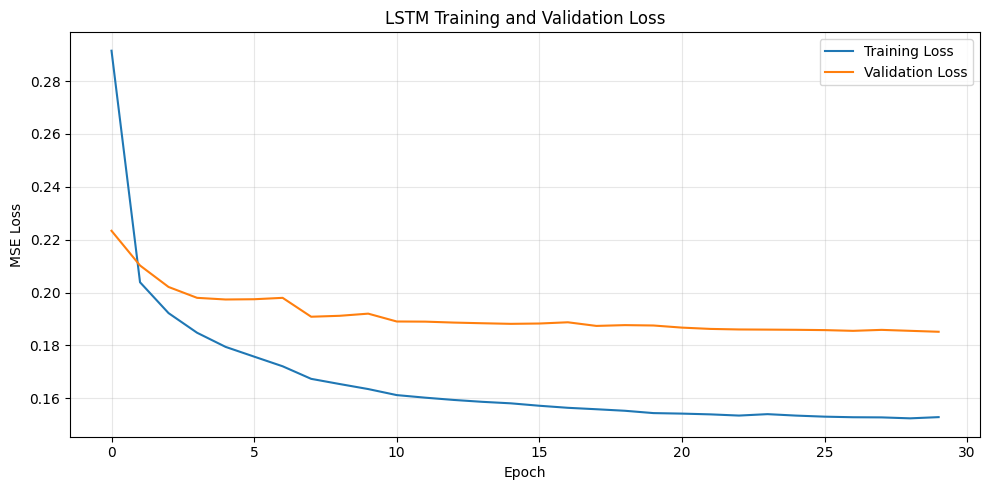

In [ ]:
# ================================================================
# LSTM TRAINING HISTORY
# ================================================================

plt.figure(figsize=(10, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("LSTM Training and Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

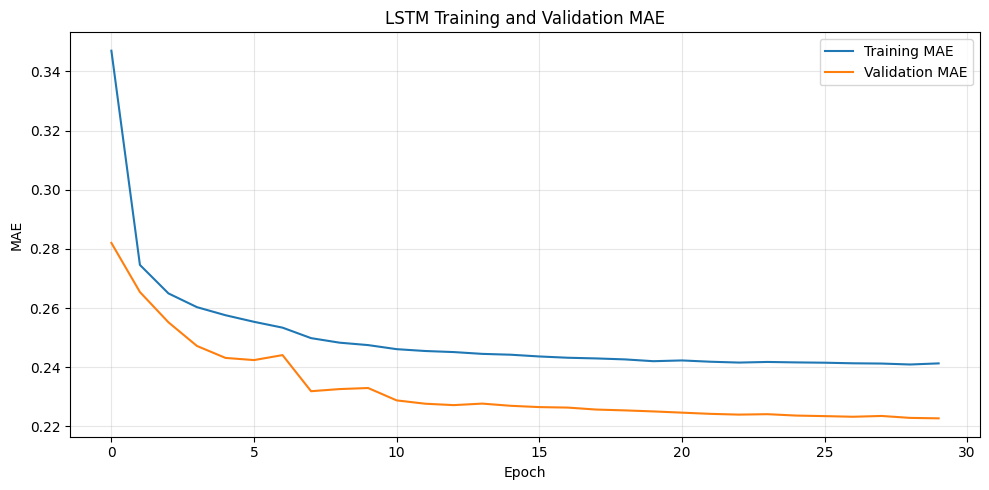

In [ ]:
# ================================================================
# LSTM TRAINING AND VALIDATION MAE
# ================================================================

plt.figure(figsize=(10, 5))

plt.plot(
    history.history["mae"],
    label="Training MAE"
)

plt.plot(
    history.history["val_mae"],
    label="Validation MAE"
)

plt.title("LSTM Training and Validation MAE")

plt.xlabel("Epoch")
plt.ylabel("MAE")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ================================================================
# LSTM — TEST SET EVALUATION
# ================================================================

test_loss, test_mae = model.evaluate(
    test_dataset
)

print("LSTM Test Loss:", test_loss)
print("LSTM Test MAE:", test_mae)

751/751 ━━━━━━━━━━━━━━━━━━━━ 48s 63ms/step - loss: 0.1886 - mae: 0.2306
LSTM Test Loss: 0.18860174715518951
LSTM Test MAE: 0.23062856495380402


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


In [ ]:
# ================================================================
# CHECK MULTI-OUTPUT PREDICTION
# ================================================================

y_pred_scaled = model.predict(
    test_dataset,
    verbose=1
)

print("Prediction shape:", y_pred_scaled.shape)
print("Target variables:", target_variables)
print("Number of targets:", len(target_variables))

751/751 ━━━━━━━━━━━━━━━━━━━━ 49s 64ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


Prediction shape: (96096, 9)
Target variables: ['temperature_c', 'humidity_pct', 'pressure_hpa', 'windspeed_kmh', 'rainfall_mm', 'windgust_kmh', 'cloudcover_pct', 'solarradiation_wm2', 'dewpoint_c']
Number of targets: 9


In [ ]:
# ================================================================
# GET ACTUAL MULTI-OUTPUT TEST VALUES
# ================================================================

y_true_scaled = []

for X_batch, y_batch in test_dataset:

    y_true_scaled.append(
        y_batch.numpy()
    )

y_true_scaled = np.concatenate(
    y_true_scaled,
    axis=0
)

print("Actual shape:", y_true_scaled.shape)
print("Prediction shape:", y_pred_scaled.shape)

Actual shape: (96096, 9)
Prediction shape: (96096, 9)


In [ ]:
# ================================================================
# CONVERT MULTI-OUTPUT PREDICTIONS BACK TO ORIGINAL UNITS
# ================================================================

# ------------------------------------------------
# Ensure correct 2D shape
# ------------------------------------------------

y_pred_scaled = np.asarray(
    y_pred_scaled
)

y_true_scaled = np.asarray(
    y_true_scaled
)

print("Scaled actual shape     :", y_true_scaled.shape)
print("Scaled prediction shape :", y_pred_scaled.shape)

print("\nExpected number of targets:",
      len(target_variables))

# ------------------------------------------------
# Check target dimension
# ------------------------------------------------

if y_pred_scaled.shape[1] != len(target_variables):
    raise ValueError(
        f"Prediction has {y_pred_scaled.shape[1]} outputs, "
        f"but target_variables contains "
        f"{len(target_variables)} targets."
    )

if y_true_scaled.shape[1] != len(target_variables):
    raise ValueError(
        f"Actual values have {y_true_scaled.shape[1]} outputs, "
        f"but target_variables contains "
        f"{len(target_variables)} targets."
    )

# ------------------------------------------------
# Convert scaled values back to original units
# ------------------------------------------------

y_true = target_scaler.inverse_transform(
    y_true_scaled
)

y_pred = target_scaler.inverse_transform(
    y_pred_scaled
)

# ------------------------------------------------
# Convert to DataFrames for easier analysis
# ------------------------------------------------

y_true_df = pd.DataFrame(
    y_true,
    columns=target_variables
)

y_pred_df = pd.DataFrame(
    y_pred,
    columns=target_variables
)

print("\nOriginal-scale actual shape     :",
      y_true.shape)

print("Original-scale prediction shape:",
      y_pred.shape)

print("\nActual values:")
display(y_true_df.head())

print("\nPredicted values:")
display(y_pred_df.head())

Scaled actual shape     : (96096, 9)
Scaled prediction shape : (96096, 9)

Expected number of targets: 9

Original-scale actual shape     : (96096, 9)
Original-scale prediction shape: (96096, 9)

Actual values:


,temperature_c,humidity_pct,pressure_hpa,windspeed_kmh,rainfall_mm,windgust_kmh,cloudcover_pct,solarradiation_wm2,dewpoint_c
0,23.900000,90.0,1010.400024,14.900000,3.000000e-01,33.500000,95.0,0.000002,22.200001
1,23.900000,90.0,1009.599976,15.700000,1.000000e-01,32.400002,98.0,0.000002,22.100000
2,23.799999,90.0,1009.099976,16.000000,-3.351548e-09,33.099998,100.0,0.000002,22.000000
3,23.699999,90.0,1008.700012,16.700001,-3.351548e-09,34.900002,100.0,0.000002,21.900000
4,23.699999,90.0,1008.900024,17.400000,-3.351548e-09,36.700001,100.0,0.000002,21.900000



Predicted values:


,temperature_c,humidity_pct,pressure_hpa,windspeed_kmh,rainfall_mm,windgust_kmh,cloudcover_pct,solarradiation_wm2,dewpoint_c
0,23.959612,90.735893,1010.268005,15.076363,0.029069,30.330486,92.852058,-14.623060,22.339260
1,23.857632,90.968941,1009.552063,13.803492,0.067998,28.343775,93.467979,-10.983290,22.324430
2,23.950310,90.344139,1008.879761,15.207605,0.124348,30.973192,95.666214,-11.764265,22.342756
3,23.900867,89.821388,1008.696350,15.661634,0.085240,31.850658,95.653252,-9.378981,22.217768
4,23.949663,89.244431,1008.482971,16.729296,0.043506,33.695110,95.079971,-7.570570,22.185825


In [ ]:
print("Target variables:")
for i, target in enumerate(target_variables):
    print(f"{i}: {target}")

Target variables:
0: temperature_c
1: humidity_pct
2: pressure_hpa
3: windspeed_kmh
4: rainfall_mm
5: windgust_kmh
6: cloudcover_pct
7: solarradiation_wm2
8: dewpoint_c


Save the trained LSTM

In [ ]:
# ================================================================
# SAVE LSTM MODEL
# ================================================================

MODEL_PATH = (
    "/content/drive/MyDrive/Capstone_Datasets/"
    "lstm_weather_forecasting.keras"
)

model.save(MODEL_PATH)

print("LSTM model saved successfully:")
print(MODEL_PATH)

LSTM model saved successfully:
/content/drive/MyDrive/Capstone_Datasets/lstm_weather_forecasting.keras


Save the predictions

In [ ]:
OUTPUT_DIR = "/content/drive/MyDrive/Capstone_Datasets"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

PREDICTION_PATH = os.path.join(
    OUTPUT_DIR,
    "LSTM_test_predictions_2025.npy"
)

np.save(
    PREDICTION_PATH,
    y_pred_df
)

print("Predictions saved successfully!")
print("Location:", PREDICTION_PATH)
print("Shape:", y_pred_df.shape)

Predictions saved successfully!
Location: /content/drive/MyDrive/Capstone_Datasets/LSTM_test_predictions_2025.npy
Shape: (96096, 9)


In [ ]:
results = []

for i, target in enumerate(target_variables):

    actual = y_true[:, i]
    predicted = y_pred[:, i]

    # Rainfall predictions cannot be negative

    if target == "rainfall_mm":
        predicted = np.maximum(predicted, 0)

    # Calculate metrics
    mae = mean_absolute_error(
        actual,
        predicted
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

    r2 = r2_score(
        actual,
        predicted
    )

    results.append({
        "Target": target,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    })


# Create results DataFrame
metrics_df = pd.DataFrame(results)



# DISPLAY RESULTS

print("=" * 70)
print("COLOMBO DISTRICT — LSTM MULTI-OUTPUT TEST PERFORMANCE")
print("=" * 70)

display(
    metrics_df.round(4)
)

COLOMBO DISTRICT — LSTM MULTI-OUTPUT TEST PERFORMANCE


,Target,MAE,RMSE,R²
0,temperature_c,0.3367,0.4790,0.9503
1,humidity_pct,1.9194,2.6345,0.9381
2,pressure_hpa,0.2604,0.3394,0.9624
3,windspeed_kmh,1.6940,2.2942,0.8785
4,rainfall_mm,0.3198,0.8666,0.3243
5,windgust_kmh,2.7417,3.7010,0.9077
6,cloudcover_pct,12.5586,19.0326,0.6395
7,solarradiation_wm2,30.7344,53.3159,0.9685
8,dewpoint_c,0.2781,0.3905,0.8906


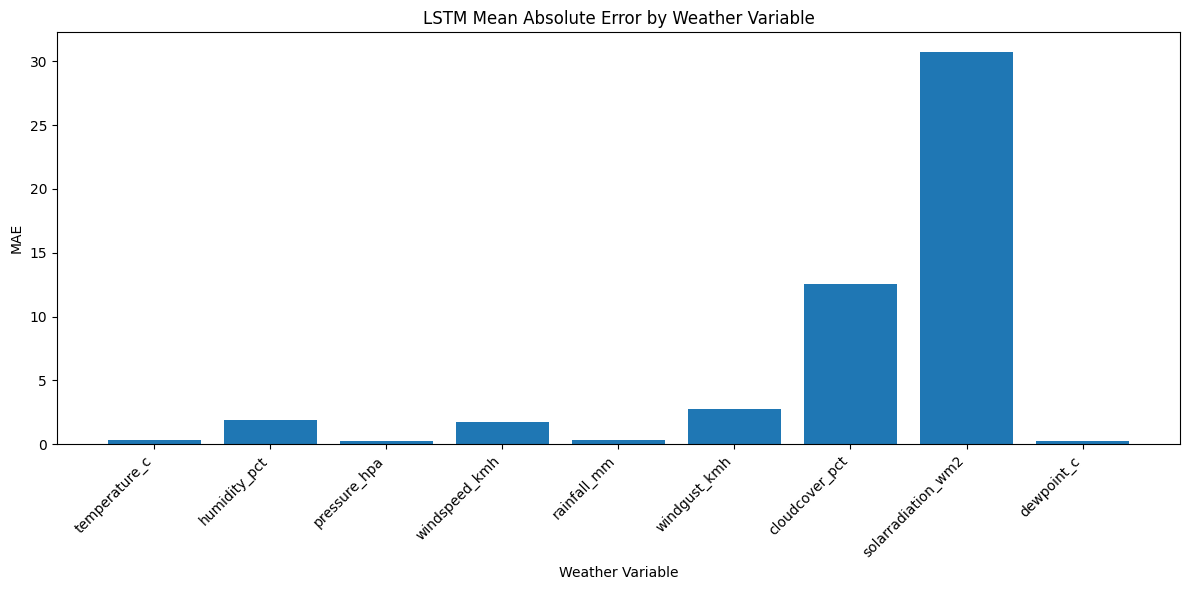

In [ ]:
# ================================================================
# MAE VISUALIZATION
# ================================================================

plt.figure(figsize=(12, 6))

plt.bar(
    metrics_df["Target"],
    metrics_df["MAE"]
)

plt.title(
    "LSTM Mean Absolute Error by Weather Variable"
)

plt.xlabel(
    "Weather Variable"
)

plt.ylabel(
    "MAE"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

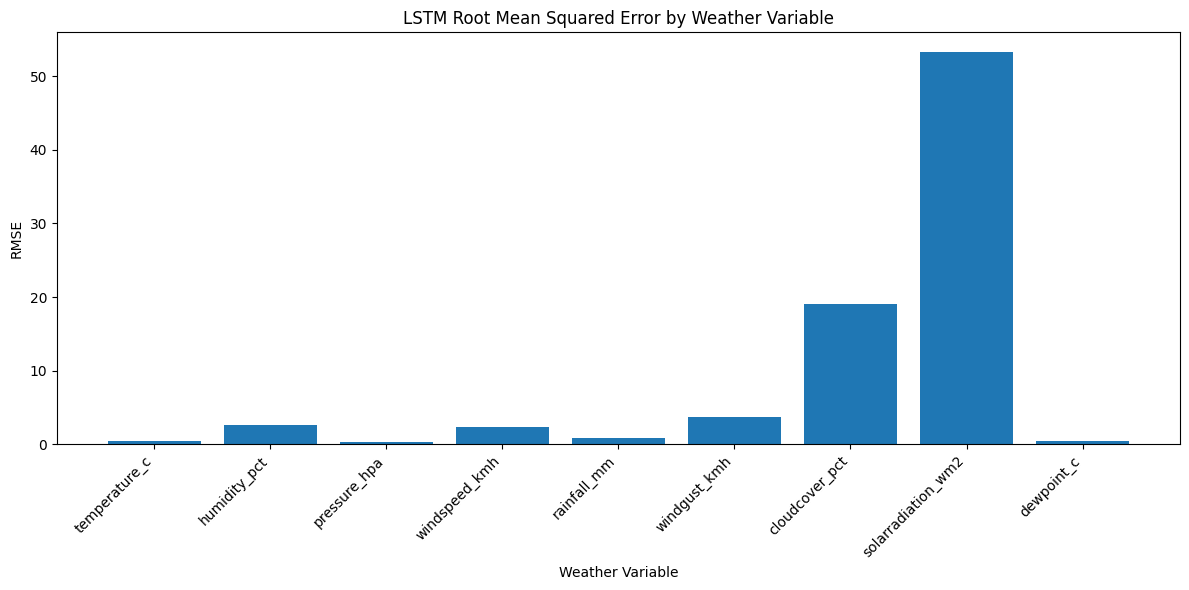

In [ ]:
# ================================================================
# RMSE VISUALIZATION
# ================================================================

plt.figure(figsize=(12, 6))

plt.bar(
    metrics_df["Target"],
    metrics_df["RMSE"]
)

plt.title(
    "LSTM Root Mean Squared Error by Weather Variable"
)

plt.xlabel(
    "Weather Variable"
)

plt.ylabel(
    "RMSE"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

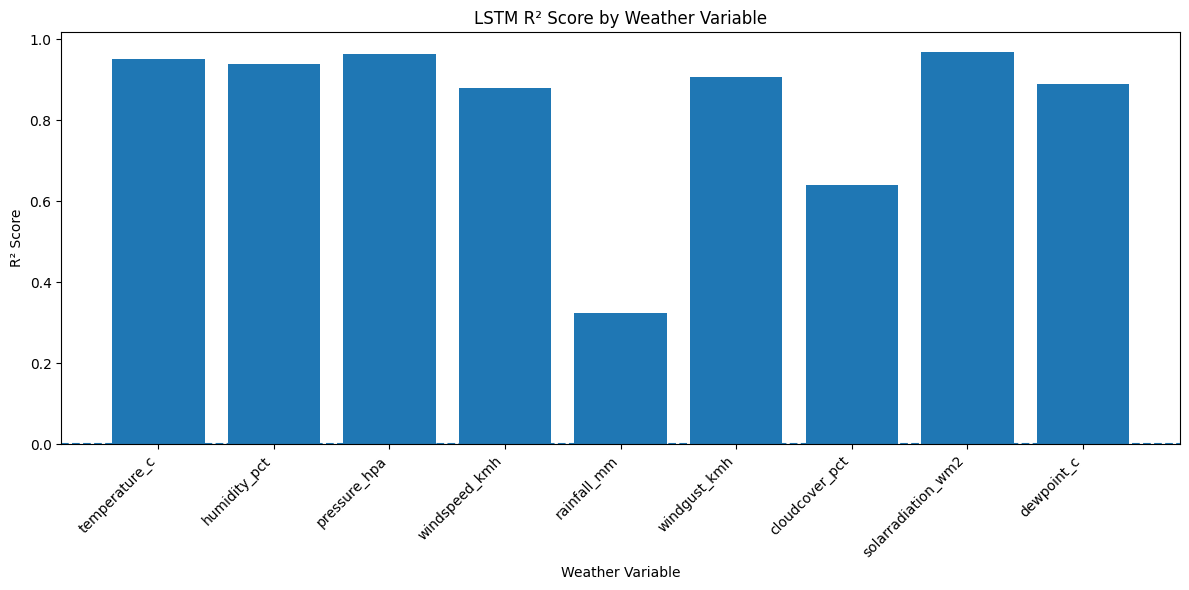

In [ ]:
# ================================================================
# R² VISUALIZATION
# ================================================================

plt.figure(figsize=(12, 6))

plt.bar(
    metrics_df["Target"],
    metrics_df["R²"]
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title(
    "LSTM R² Score by Weather Variable"
)

plt.xlabel(
    "Weather Variable"
)

plt.ylabel(
    "R² Score"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

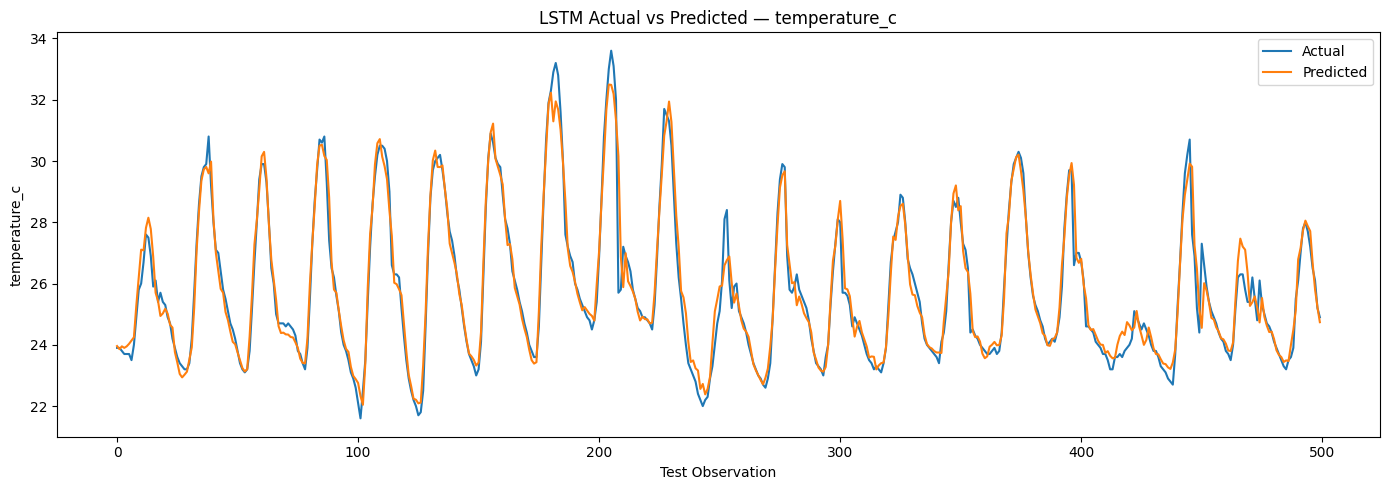

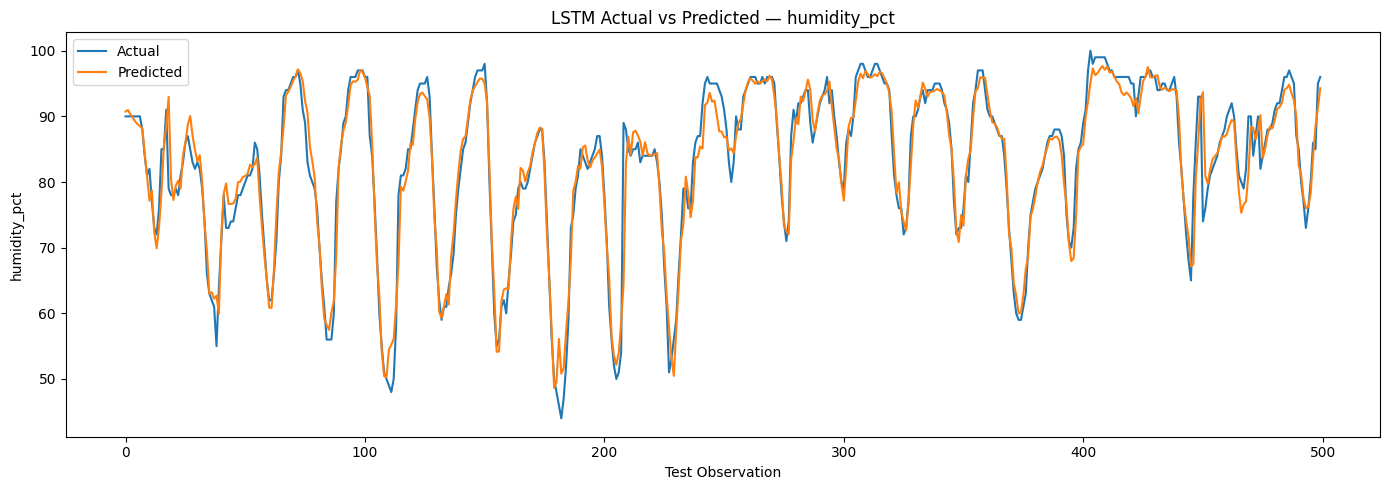

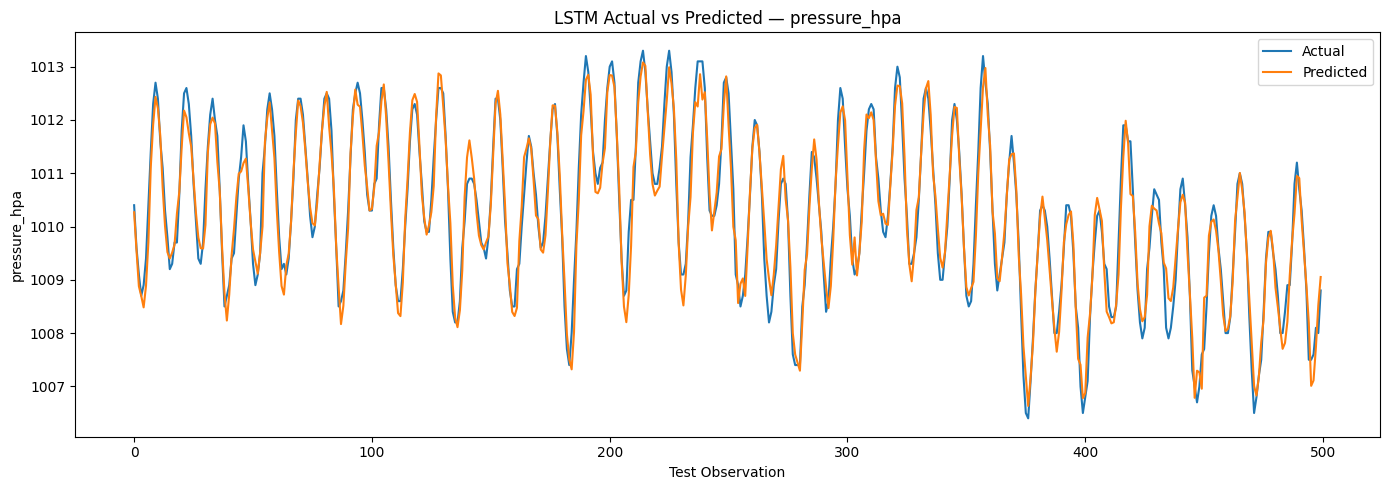

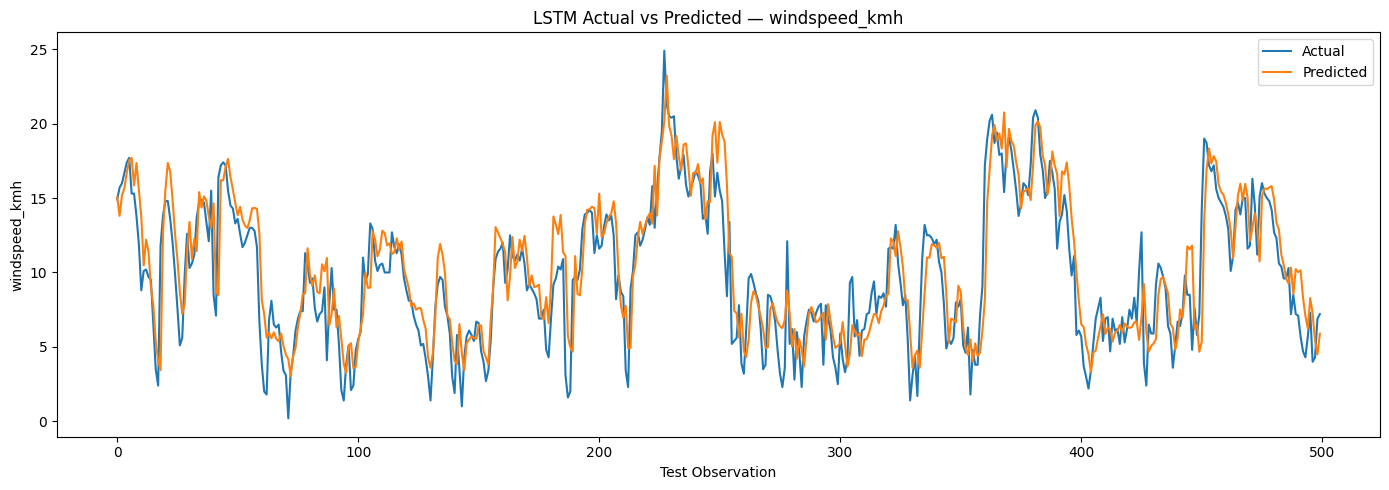

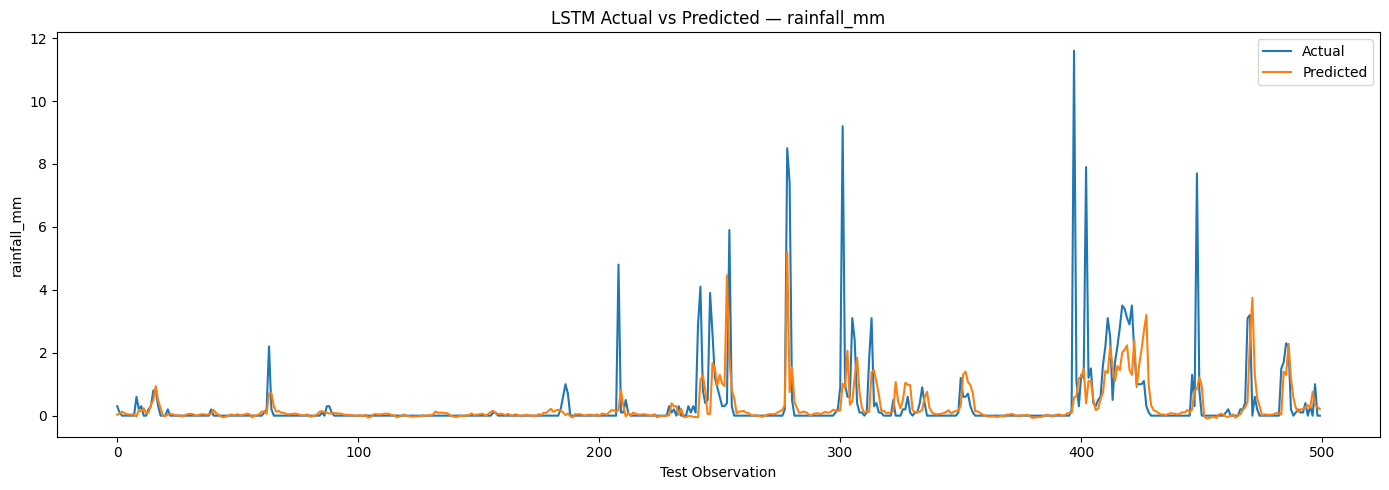

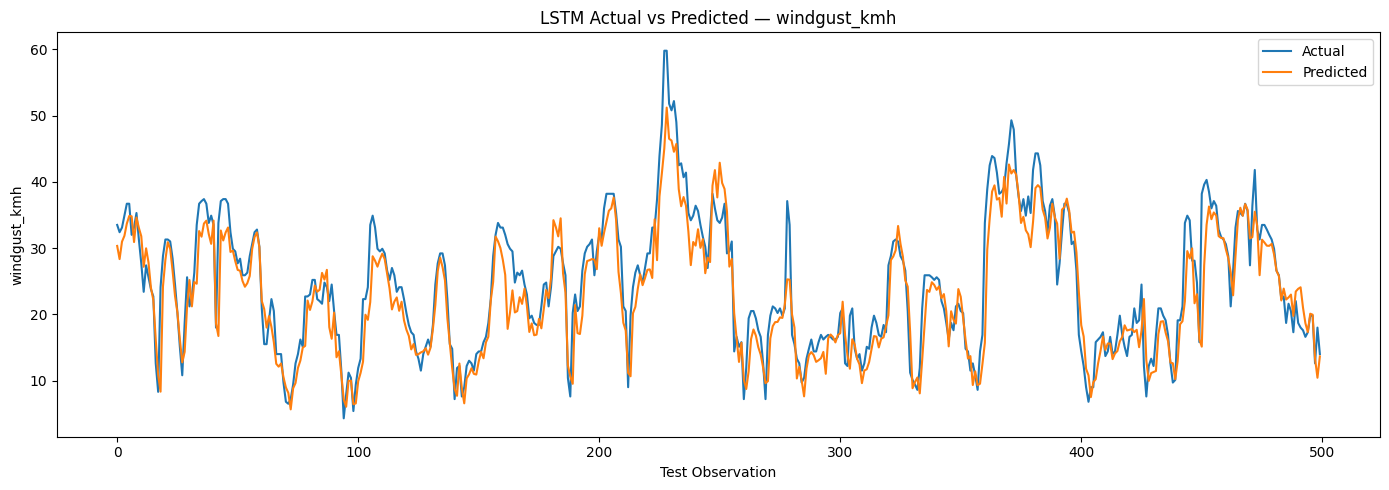

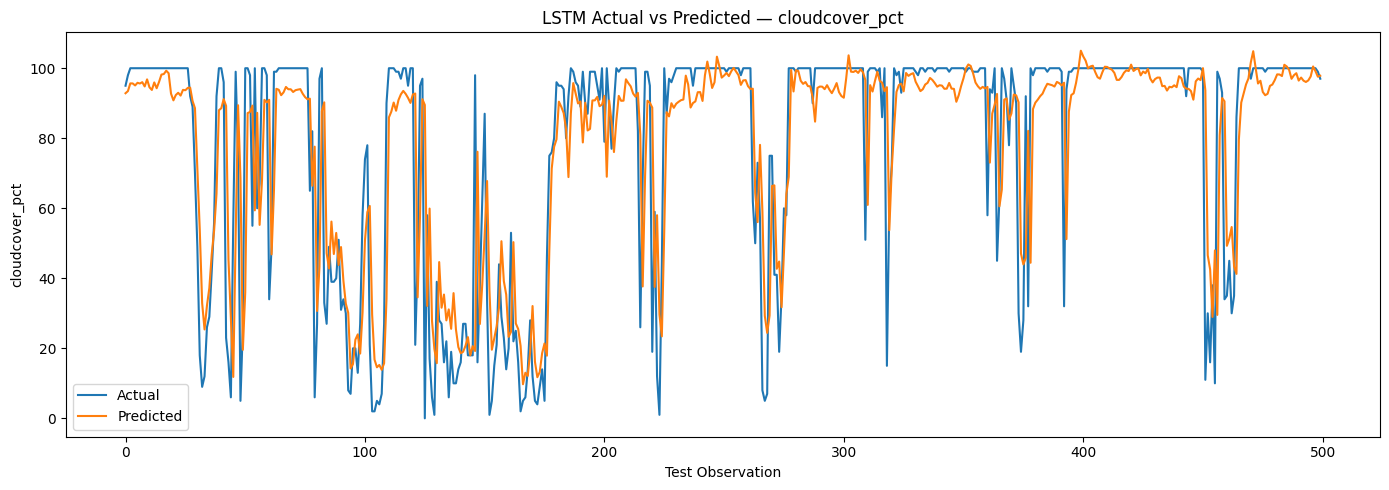

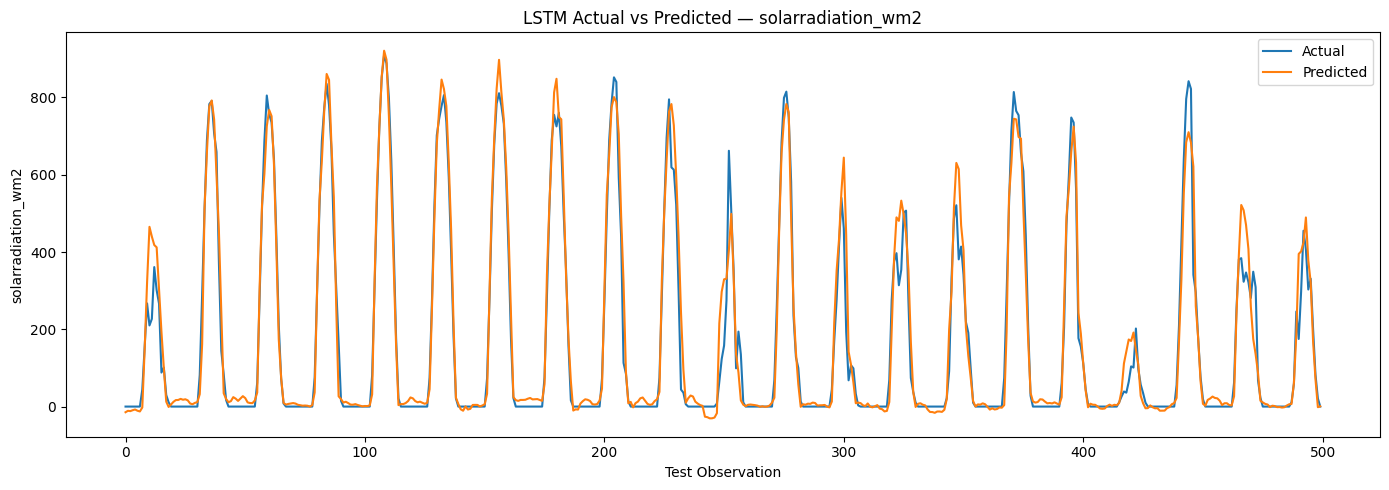

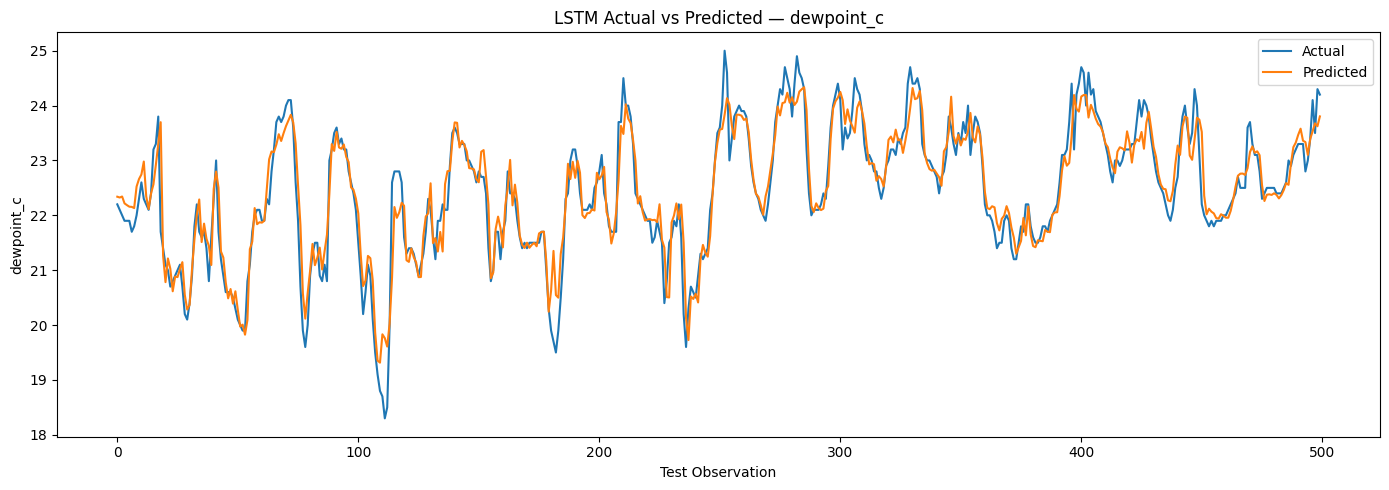

In [ ]:
# ================================================================
# ACTUAL VS PREDICTED — FIRST 500 TEST OBSERVATIONS
# ================================================================

N = 500

for i, target in enumerate(target_variables):

    plt.figure(figsize=(14, 5))

    plt.plot(
        y_true[:N, i],
        label="Actual"
    )

    plt.plot(
        y_pred[:N, i],
        label="Predicted"
    )

    plt.title(
        f"LSTM Actual vs Predicted — {target}"
    )

    plt.xlabel(
        "Test Observation"
    )

    plt.ylabel(
        target
    )

    plt.legend()

    plt.tight_layout()

    plt.show()

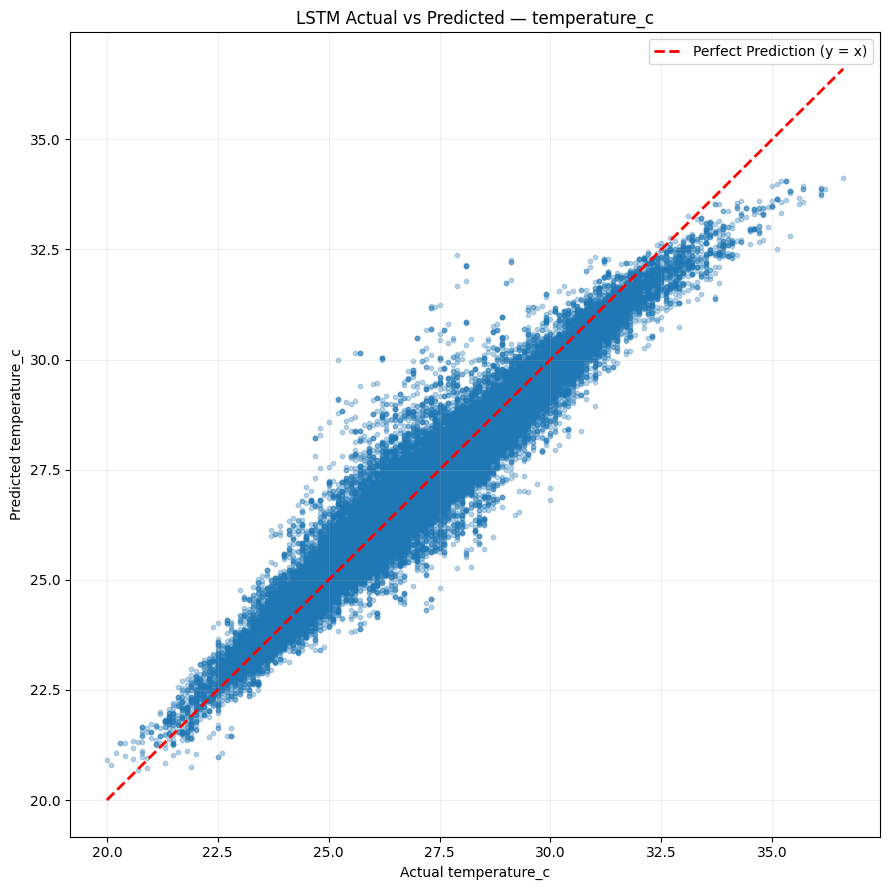

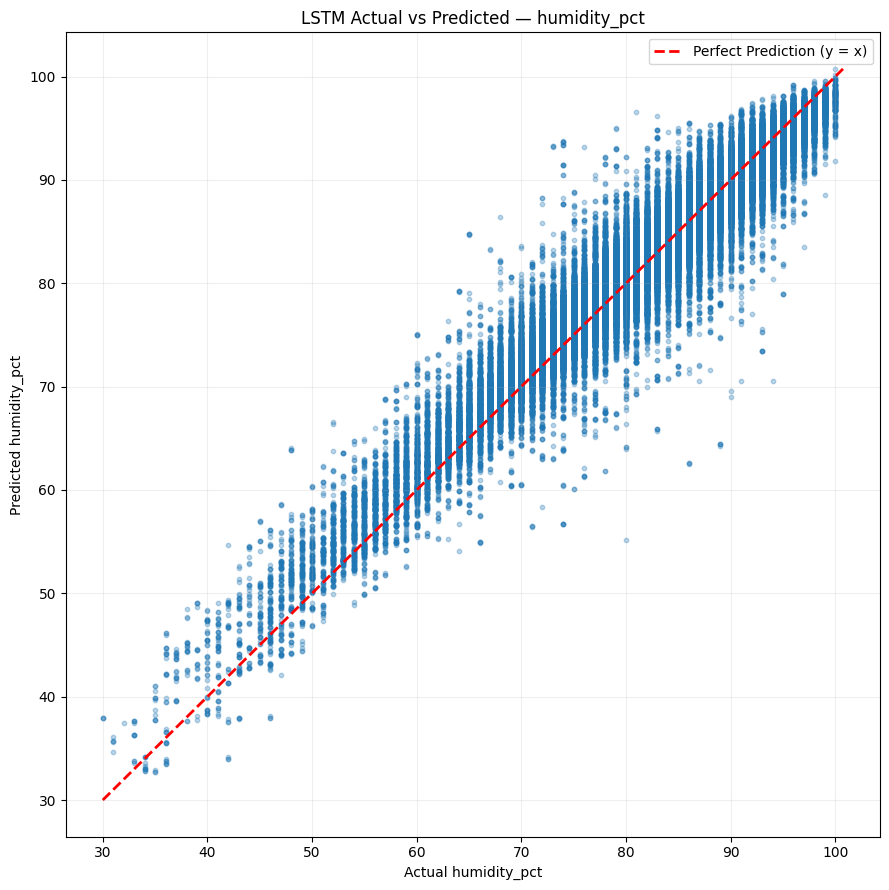

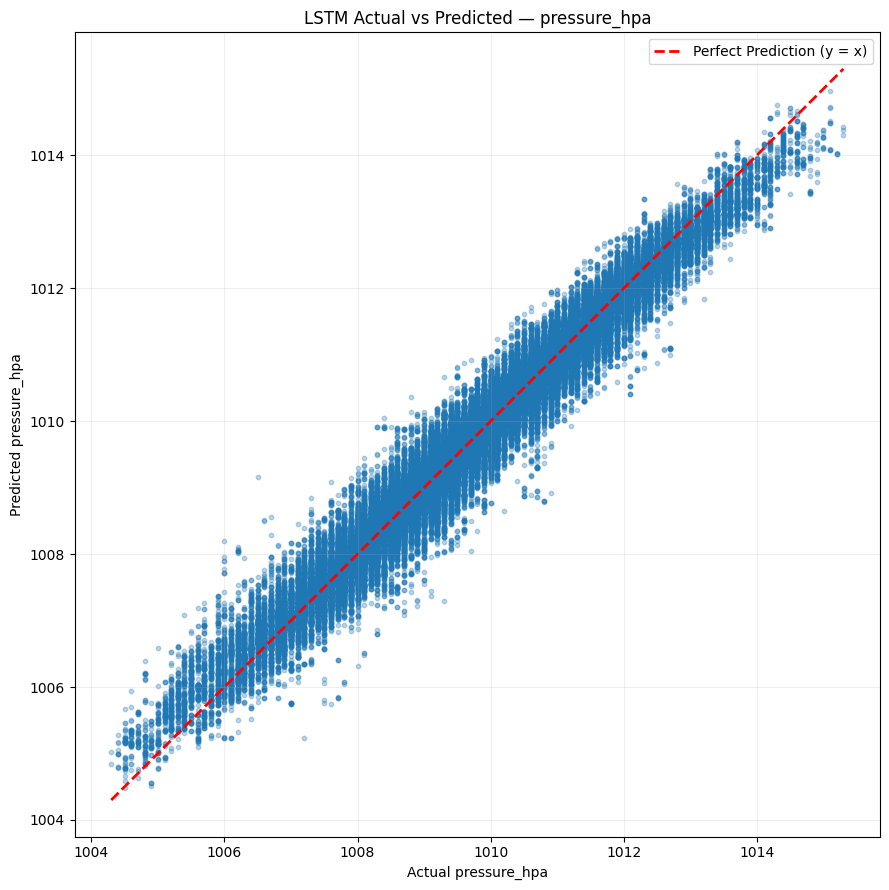

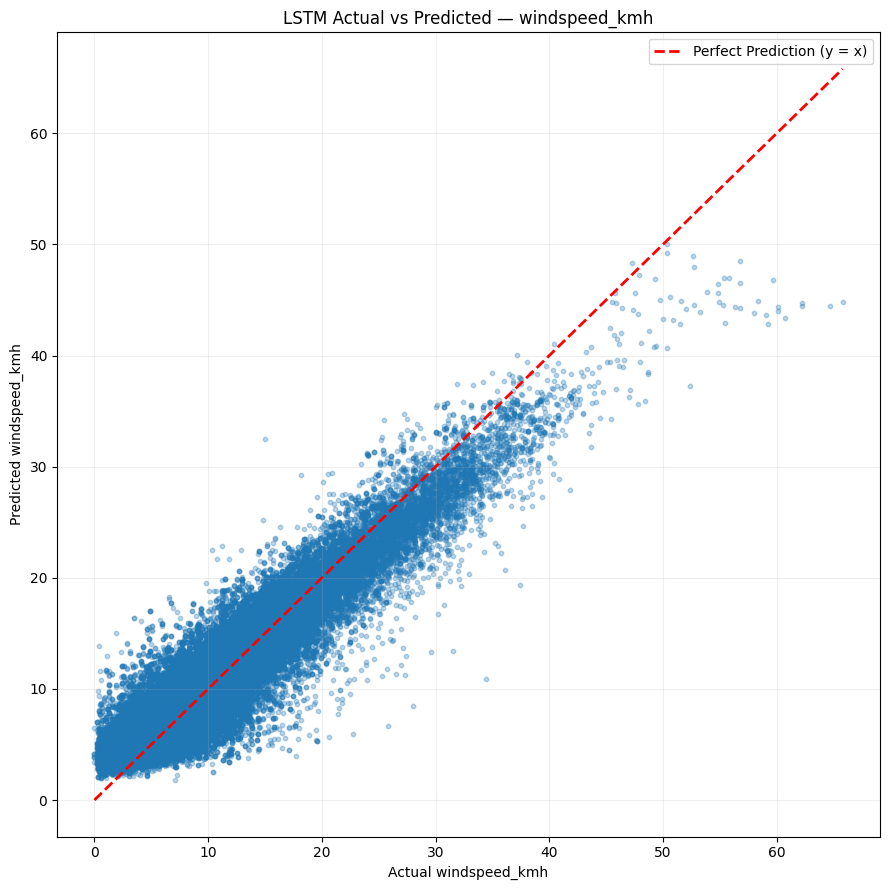

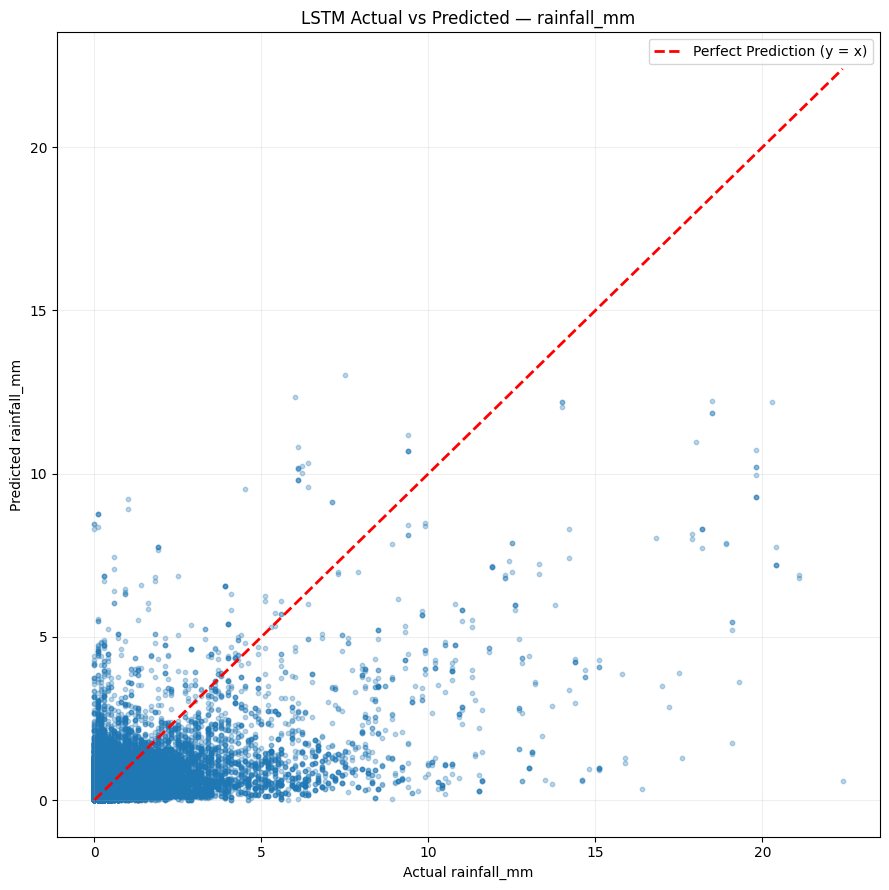

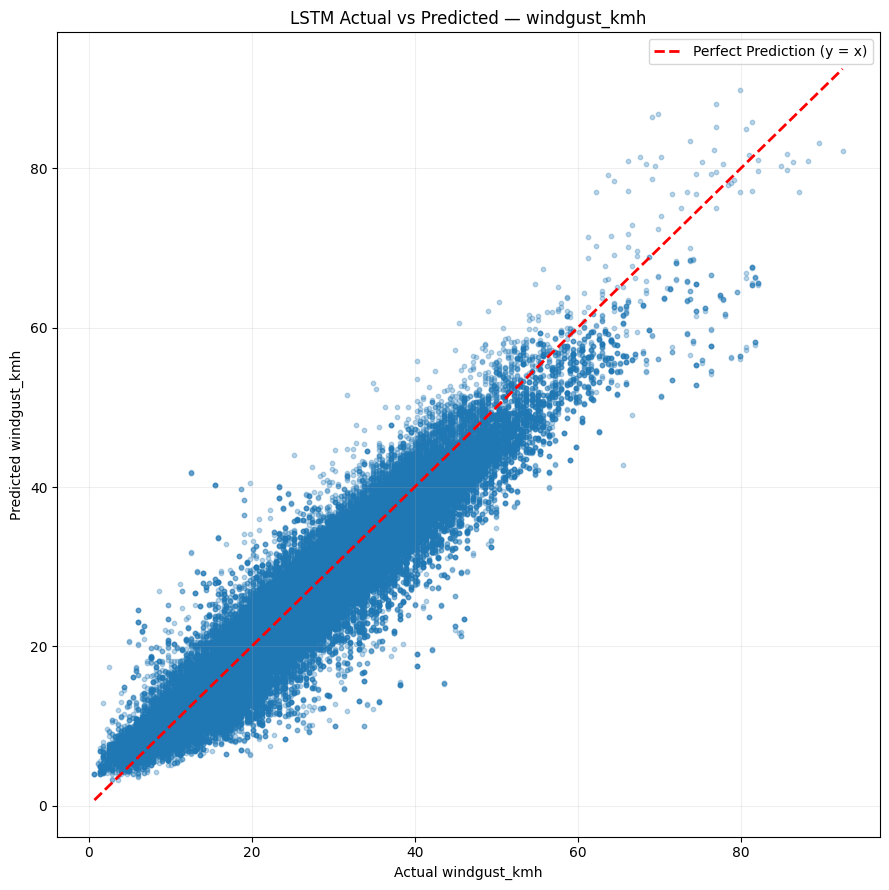

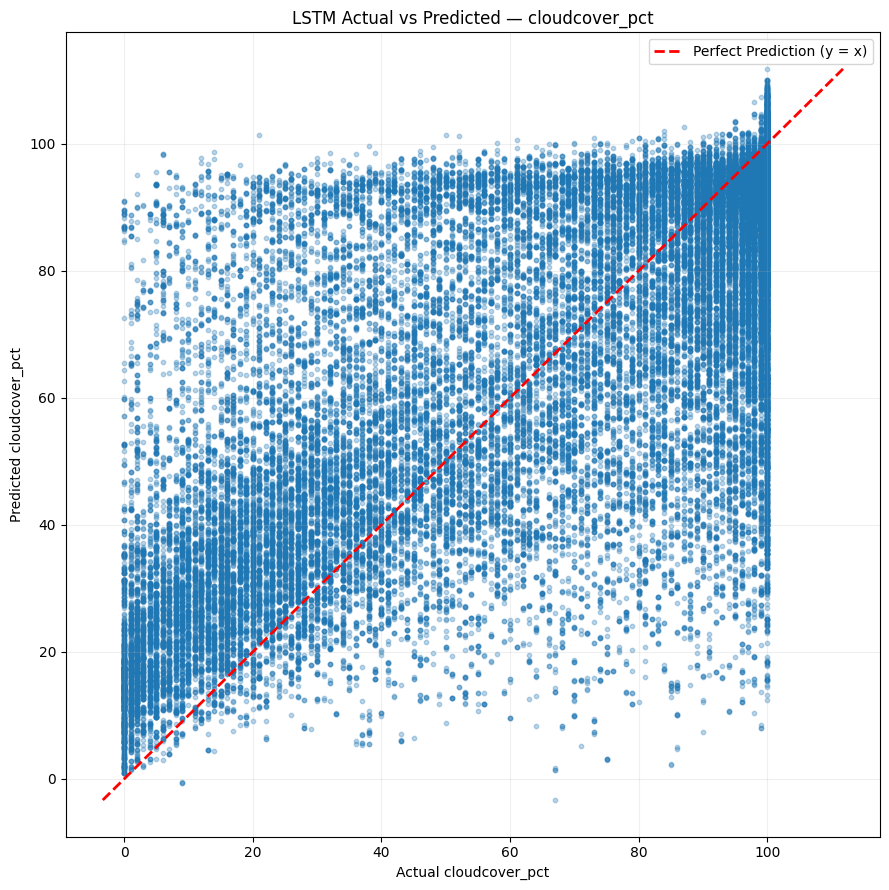

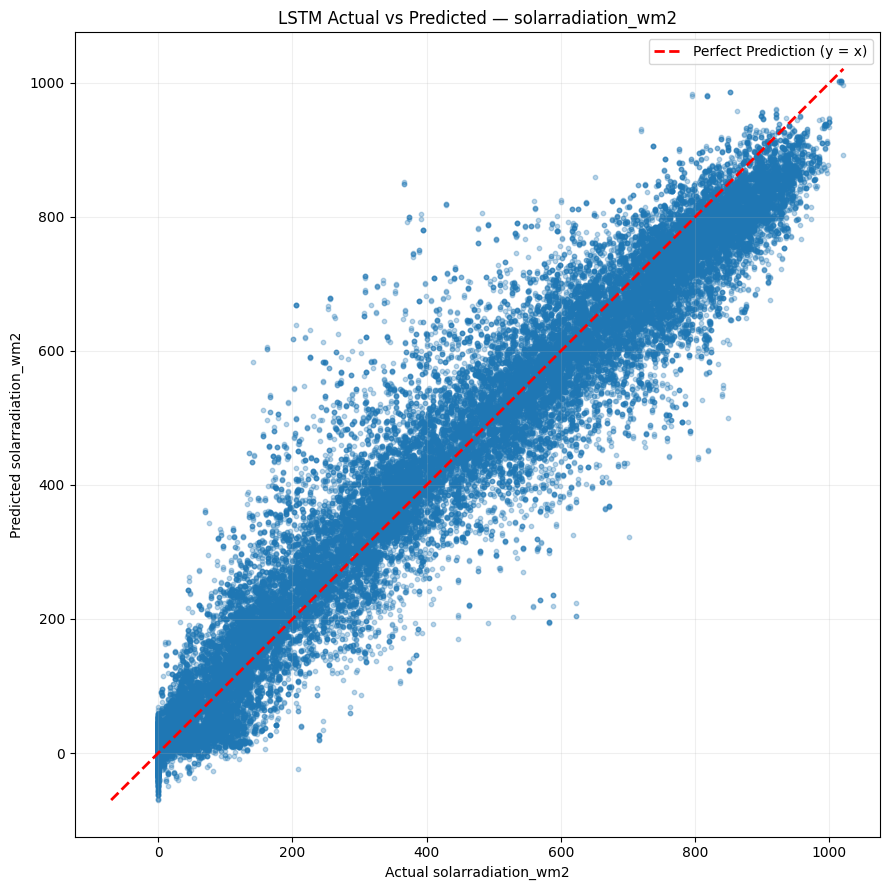

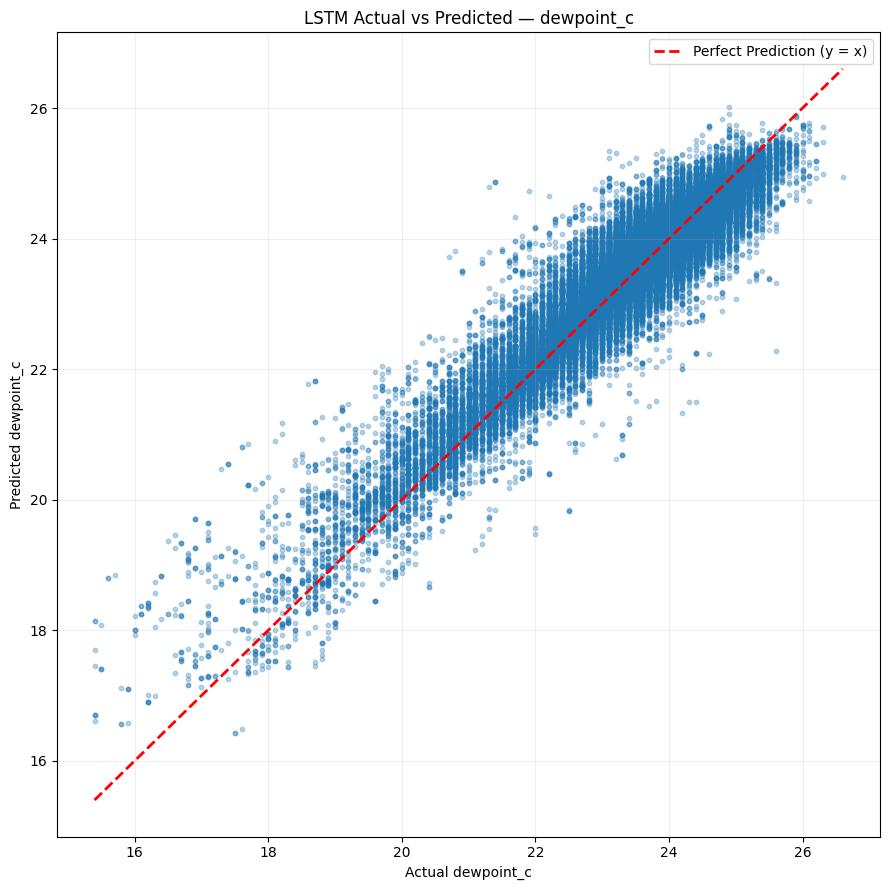

In [ ]:
# ================================================================
# ACTUAL VS PREDICTED SCATTER PLOTS
# ================================================================

for i, target in enumerate(target_variables):

    actual = y_true[:, i]
    predicted = y_pred[:, i]

    # ------------------------------------------------------------
    # Prevent negative rainfall predictions
    # ------------------------------------------------------------

    if target == "rainfall_mm":
        predicted = np.maximum(
            predicted,
            0
        )

    # ------------------------------------------------------------
    # Create scatter plot
    # ------------------------------------------------------------

    plt.figure(figsize=(9, 9))

    plt.scatter(
        actual,
        predicted,
        alpha=0.3,
        s=10
    )

    # ------------------------------------------------------------
    # Perfect prediction line
    # Predicted = Actual
    # ------------------------------------------------------------

    min_value = min(
        actual.min(),
        predicted.min()
    )

    max_value = max(
        actual.max(),
        predicted.max()
    )

    plt.plot(
        [min_value, max_value],
        [min_value, max_value],
        color="red",
        linestyle="--",
        linewidth=2,
        label="Perfect Prediction (y = x)"
    )

    # ------------------------------------------------------------
    # Labels and title
    # ------------------------------------------------------------

    plt.title(
        f"LSTM Actual vs Predicted — {target}"
    )

    plt.xlabel(
        f"Actual {target}"
    )

    plt.ylabel(
        f"Predicted {target}"
    )

    plt.legend()

    plt.grid(
        alpha=0.2
    )

    plt.tight_layout()

    plt.show()

In [ ]:
rainfall_index = target_variables.index(
    "rainfall_mm"
)


actual_rainfall = y_true[
    :,
    rainfall_index
]

predicted_rainfall = y_pred[
    :,
    rainfall_index
]

In [ ]:
# ================================================================
# RAIN / NO-RAIN PERFORMANCE
# ================================================================

RAIN_THRESHOLD = 0.1

actual_rain = (
    actual_rainfall >= RAIN_THRESHOLD
).astype(int)

predicted_rain = (
    predicted_rainfall >= RAIN_THRESHOLD
).astype(int)

accuracy = accuracy_score(
    actual_rain,
    predicted_rain
)

precision = precision_score(
    actual_rain,
    predicted_rain,
    zero_division=0
)

recall = recall_score(
    actual_rain,
    predicted_rain,
    zero_division=0
)

f1 = f1_score(
    actual_rain,
    predicted_rain,
    zero_division=0
)

print("=" * 60)
print("COLOMBO DISTRICT — LSTM RAIN / NO-RAIN PERFORMANCE")
print("=" * 60)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

COLOMBO DISTRICT — LSTM RAIN / NO-RAIN PERFORMANCE
Accuracy  : 0.7251
Precision : 0.6352
Recall    : 0.8615
F1 Score  : 0.7313


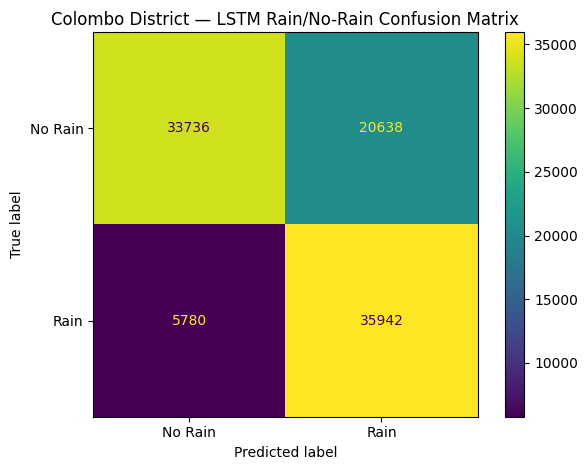

In [ ]:
# ================================================================
# RAIN / NO-RAIN CONFUSION MATRIX
# ================================================================

cm = confusion_matrix(
    actual_rain,
    predicted_rain
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "No Rain",
        "Rain"
    ]
)

disp.plot()

plt.title(
    "Colombo District — LSTM Rain/No-Rain Confusion Matrix"
)

plt.tight_layout()
plt.show()